**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [8]:
# ---- Experiment settings ----
TAG = "only-essays-v1"
SCHEMA_DATE = "230726"

# ---- Paths ----
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
# FILE_NAME_VALIDATION_DATA = "Experimental Results Annealing V2 - CompiledResults.csv"

PROCESS = "annealing_elongation"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "elongation_final"
FEATURES = ["initial_diameter", "tensile_strength", "purity", "elongation", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [10]:
# Schema dataset. Mark essay rows EXPLICITLY (used later for weight_col).
df_raw_schema = pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema["is_essay"] = True
df_schema


,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay
4,2.160000,391.690000,99.9000,4.90%,573.0,30.0,48.60%,True
5,2.182333,387.595254,99.9000,6.02%,573.0,30.0,56.21%,True
11,1.200000,431.580000,99.9000,0.94%,523.0,30.0,20.15%,True
12,1.200000,431.580000,99.9000,0.94%,523.0,60.0,22.04%,True
13,1.200000,431.580000,99.9000,0.94%,523.0,90.0,24.62%,True
14,1.200000,431.580000,99.9000,0.94%,573.0,30.0,24.72%,True
15,1.200000,431.580000,99.9000,0.94%,573.0,60.0,27.43%,True
16,1.200000,431.580000,99.9000,0.94%,573.0,90.0,25.24%,True
17,1.200000,431.580000,99.9000,0.94%,623.0,30.0,27.06%,True
18,1.200000,431.580000,99.9000,0.94%,623.0,60.0,26.17%,True


## 2.3 Concat dataset

In [15]:
# df = pd.concat([df_schema, df_lit], ignore_index=True)
df = df_schema.reset_index(drop=True).copy()
df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

df["elongation"] = pd.to_numeric(
    df["elongation"].astype(str).str.replace("%", "", regex=False).str.strip(), errors="coerce"
)
df["elongation_final"] = pd.to_numeric(
    df["elongation_final"].astype(str).str.replace("%", "", regex=False).str.strip(),
    errors="coerce",
)

# # Optional shared fold column: the SAME partition is passed to AutoGluon
# # (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
# if USE_SHARED_FOLDS:
#     df = feng.add_stratified_fold_column(
#         df, n_folds=NUM_BAG_FOLDS_A, seed=FOLD_SEED,
#     )

# df

df

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62,True,1.0
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,True,1.0
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,True,1.0
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,True,1.0
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17,True,1.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   initial_diameter  28 non-null     float64
 1   tensile_strength  28 non-null     float64
 2   purity            28 non-null     float64
 3   elongation        28 non-null     float64
 4   temperature       28 non-null     float64
 5   time              28 non-null     float64
 6   elongation_final  28 non-null     float64
 7   is_essay          28 non-null     bool   
 8   weight_col        28 non-null     float64
dtypes: bool(1), float64(8)
memory usage: 1.9 KB


## 2.4 Validation data

In [8]:
# # ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [17]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62,True,1.0
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72,True,1.0
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24,True,1.0
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06,True,1.0
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17,True,1.0


In [18]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.43 GB / 31.57 GB (14.0%)
Disk Space Avail:   732.66 GB / 932.08 GB (78.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v1\model_a"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       elongation_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (61.1, 8.55, 39.1, 13.49557)
	If 'regression' is

In [19]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-8.292139,root_mean_squared_error,0.046556,10.287596,0.000000,0.010003,2,True,10
1,NeuralNetTorch_BAG_L1,-8.432435,root_mean_squared_error,0.040001,8.771902,0.040001,8.771902,1,True,8
2,LightGBMLarge_BAG_L1,-9.129597,root_mean_squared_error,0.006555,1.505691,0.006555,1.505691,1,True,9
3,XGBoost_BAG_L1,-10.600081,root_mean_squared_error,0.012574,1.072567,0.012574,1.072567,1,True,7
4,CatBoost_BAG_L1,-10.782491,root_mean_squared_error,0.006999,1.665704,0.006999,1.665704,1,True,4
5,ExtraTreesMSE_BAG_L1,-11.605972,root_mean_squared_error,0.044551,0.445988,0.044551,0.445988,1,True,5
6,RandomForestMSE_BAG_L1,-12.997589,root_mean_squared_error,0.038100,0.440560,0.038100,0.440560,1,True,3
7,LightGBM_BAG_L1,-14.073020,root_mean_squared_error,0.003546,1.468323,0.003546,1.468323,1,True,2
8,LightGBMXT_BAG_L1,-14.073020,root_mean_squared_error,0.007998,0.531091,0.007998,0.531091,1,True,1
9,NeuralNetFastAI_BAG_L1,-14.210583,root_mean_squared_error,0.071216,7.268005,0.071216,7.268005,1,True,6


In [20]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-8.292139,root_mean_squared_error,0.046556,10.287596,0.000000,0.010003,2,True,10
1,NeuralNetTorch_BAG_L1,-8.432435,root_mean_squared_error,0.040001,8.771902,0.040001,8.771902,1,True,8
2,LightGBMLarge_BAG_L1,-9.129597,root_mean_squared_error,0.006555,1.505691,0.006555,1.505691,1,True,9
3,XGBoost_BAG_L1,-10.600081,root_mean_squared_error,0.012574,1.072567,0.012574,1.072567,1,True,7
4,CatBoost_BAG_L1,-10.782491,root_mean_squared_error,0.006999,1.665704,0.006999,1.665704,1,True,4
5,ExtraTreesMSE_BAG_L1,-11.605972,root_mean_squared_error,0.044551,0.445988,0.044551,0.445988,1,True,5
6,RandomForestMSE_BAG_L1,-12.997589,root_mean_squared_error,0.038100,0.440560,0.038100,0.440560,1,True,3
7,LightGBM_BAG_L1,-14.073020,root_mean_squared_error,0.003546,1.468323,0.003546,1.468323,1,True,2
8,LightGBMXT_BAG_L1,-14.073020,root_mean_squared_error,0.007998,0.531091,0.007998,0.531091,1,True,1
9,NeuralNetFastAI_BAG_L1,-14.210583,root_mean_squared_error,0.071216,7.268005,0.071216,7.268005,1,True,6


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [21]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    exclude_algos=["DeepLearning"],
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,37 mins 15 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 11 days
H2O_cluster_name:,H2O_from_python_fmfoa_lpbgd9
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.322 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
19:14:12.999: AutoML: XGBoost is not available; skipping it.
19:14:13.73: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 28.0.
19:14:13.446: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
19:14:13.568: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
19:14:13.946: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_2_20260723_191412_model_592,9.17216,84.1285,5.32402,0.32934,84.1285
GBM_grid_1_AutoML_2_20260723_191412_model_89,9.19613,84.5687,5.21143,0.331241,84.5687
GBM_grid_1_AutoML_2_20260723_191412_model_183,9.34437,87.3173,5.25937,0.332741,87.3173
GBM_grid_1_AutoML_2_20260723_191412_model_720,9.36874,87.7733,4.88948,0.332931,87.7733
GBM_grid_1_AutoML_2_20260723_191412_model_406,9.4402,89.1173,5.31971,0.335676,89.1173
GBM_grid_1_AutoML_2_20260723_191412_model_30,9.47466,89.7693,5.32579,0.333073,89.7693
GBM_grid_1_AutoML_2_20260723_191412_model_78,9.48566,89.9777,5.10773,0.336748,89.9777
GBM_grid_1_AutoML_2_20260723_191412_model_117,9.49783,90.2088,5.13096,0.33653,90.2088
GBM_grid_1_AutoML_2_20260723_191412_model_624,9.51673,90.5681,5.26118,0.336282,90.5681
GBM_grid_1_AutoML_2_20260723_191412_model_558,9.51702,90.5736,5.3685,0.336586,90.5736


In [22]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [23]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(28,)  any NaN? False


## 4.1 fast check on big residuals

In [24]:
residuals_oof.head(10)

0    1.780969
1    8.080312
2   -3.855817
3   -3.198947
4   -1.482465
5   -6.897105
6   -6.587567
7   -8.958963
8   -5.072523
9   -5.940603
Name: elongation_final, dtype: float64

In [25]:
df[residuals_oof.abs() > 2]

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,True,1.0
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,True,1.0
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,True,1.0
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,True,1.0
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,True,1.0
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17,True,1.0
12,1.200000,397.090000,99.9000,2.36,573.0,30.0,44.18,True,1.0
14,1.200000,397.090000,99.9000,2.36,573.0,90.0,43.64,True,1.0


In [26]:
mu_oof[residuals_oof.abs() > 2]

1     48.129688
2     24.005817
3     25.238947
5     31.617105
6     34.017567
7     34.198963
8     32.132523
9     32.110603
12    35.801674
14    45.828667
15    43.412533
16    42.401775
18    43.717529
19    48.215012
21    43.830517
22    46.327991
24    46.409988
25    44.101830
26    52.078125
27    55.249760
Name: elongation_final, dtype: float32

## 4.2 Recovering weights 

In [27]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 28)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [28]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000002  (OK)

Non-zero weights:
  NeuralNetTorch_BAG_L1           0.7143
  LightGBMLarge_BAG_L1            0.2857


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [29]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    2.800000e+01
mean     7.211340e-07
std      5.022340e-07
min      4.495873e-08
25%      3.490973e-07
50%      5.358654e-07
75%      1.049313e-06
max      1.841850e-06
Name: elongation_final, dtype: float64

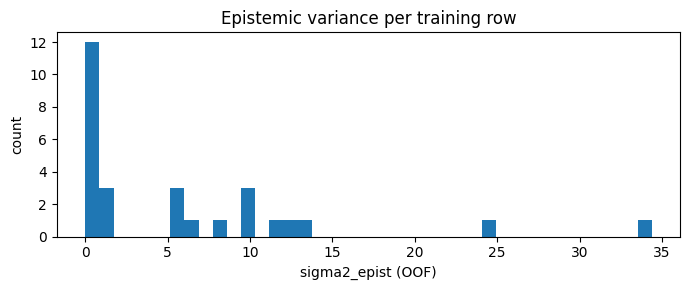

In [30]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [31]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    28.000000
mean      3.343392
std       3.479509
min       0.015152
25%       0.718921
50%       3.263298
75%       4.360142
max      15.288185
Name: elongation_final, dtype: float64

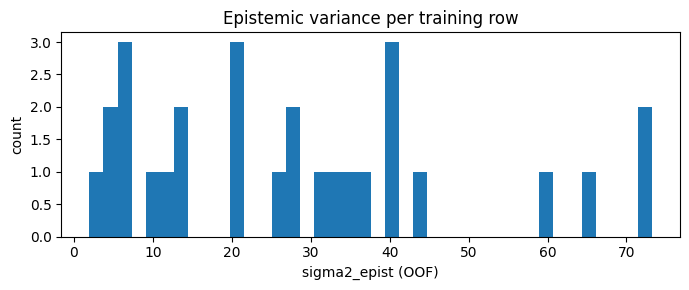

In [32]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [33]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 28
  n_truncated          = 7
  pct_truncated        = 25.0
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 1263.9013434320386
  r_tilde_sq_mean      = 63.724548003457265
  r_tilde_sq_median    = 6.525265048393003


In [34]:
r_tilde_sq

array([0.00000000e+00, 5.26167117e+01, 6.84315513e+00, 4.42239579e+00,
       0.00000000e+00, 3.63718232e+01, 4.33718869e+01, 8.01900590e+01,
       1.90891863e+01, 2.95061886e+01, 0.00000000e+00, 0.00000000e+00,
       6.06709281e+01, 9.69859482e-01, 3.76480532e+00, 2.09338660e+01,
       6.59250906e+00, 0.00000000e+00, 5.04970366e+00, 5.30276627e+00,
       1.82460197e+00, 5.11447882e+01, 0.00000000e+00, 0.00000000e+00,
       6.45802104e+00, 1.26390134e+03, 5.72029202e+01, 2.80598248e+01])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [35]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.38 GB / 31.57 GB (20.2%)
Disk Space Avail:   732.61 GB / 932.08 GB (78.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\only-essays-v1\model_b"
Train Data Rows:    28
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (7.141958521369611, -13.815510557964274, -1.31122, 

In [36]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.548624,root_mean_squared_error,0.054930,11.841414,0.000999,0.013515,2,True,10
1,NeuralNetTorch_BAG_L1,-6.589104,root_mean_squared_error,0.037508,9.208345,0.037508,9.208345,1,True,8
2,LightGBMLarge_BAG_L1,-7.080146,root_mean_squared_error,0.003999,1.801902,0.003999,1.801902,1,True,9
3,XGBoost_BAG_L1,-7.387253,root_mean_squared_error,0.012425,0.817652,0.012425,0.817652,1,True,7
4,CatBoost_BAG_L1,-7.555578,root_mean_squared_error,0.009166,10.390193,0.009166,10.390193,1,True,4
5,ExtraTreesMSE_BAG_L1,-7.800266,root_mean_squared_error,0.056777,0.437517,0.056777,0.437517,1,True,5
6,RandomForestMSE_BAG_L1,-7.852539,root_mean_squared_error,0.045109,0.486106,0.045109,0.486106,1,True,3
7,LightGBMXT_BAG_L1,-7.975641,root_mean_squared_error,0.001977,1.116905,0.001977,1.116905,1,True,1
8,LightGBM_BAG_L1,-7.975641,root_mean_squared_error,0.003521,1.416451,0.003521,1.416451,1,True,2
9,NeuralNetFastAI_BAG_L1,-8.074717,root_mean_squared_error,0.041000,7.490064,0.041000,7.490064,1,True,6


In [37]:
predictor_b.predict_oof()  

0    -1.231362
1    -0.136717
2    -2.602877
3    -0.177611
4    -4.783683
5     0.237891
6     2.266284
7     1.985943
8     0.062792
9    -0.071534
10   -2.326249
11   -0.188898
12   -0.224276
13    0.744395
14   -1.471813
15    0.360366
16    0.350994
17   -2.257315
18    1.053433
19   -0.686956
20   -0.833456
21   -2.454620
22   -2.533448
23   -4.525732
24   -1.590903
25   -2.304075
26   -0.529520
27    0.372657
Name: log_r_tilde_sq, dtype: float32

In [39]:
df_lado_a_lado = pd.DataFrame({
    "residual_oof": residuals_oof,
    "predict_random_error": predictor_b.predict_oof()  , 
    "epistemic_error": sigma2_epist_oof,
    f"{TARGET}": df[f"{TARGET}"],
    f"{TARGET}_final": df[TARGET]
}) 
df_lado_a_lado

,residual_oof,predict_random_error,epistemic_error,elongation_final,elongation_final_final
0,1.780969,-1.231362,13.425229,48.60,48.60
1,8.080312,-0.136717,12.674726,56.21,56.21
2,-3.855817,-2.602877,8.024173,20.15,20.15
3,-3.198947,-0.177611,5.810866,22.04,22.04
4,-1.482465,-4.783683,5.383233,24.62,24.62
5,-6.897105,0.237891,11.198241,24.72,24.72
6,-6.587567,2.266284,0.024148,27.43,27.43
7,-8.958963,1.985943,0.072962,25.24,25.24
8,-5.072523,0.062792,6.641299,27.06,27.06
9,-5.940603,-0.071534,5.784579,26.17,26.17


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [40]:
df[TARGET].var()

np.float64(182.1305037037037)

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [41]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.214286,-0.285714
1,0.80,0.428571,-0.371429
2,0.90,0.500000,-0.400000
3,0.95,0.678571,-0.271429


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [42]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 2.4098

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.500000,0.000000
1,0.80,0.821429,0.021429
2,0.90,0.857143,-0.042857
3,0.95,0.857143,-0.092857


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [43]:
c_opt
weights

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       3.70478714e-08, 0.00000000e+00, 0.00000000e+00, 7.14285771e-01,
       2.85714192e-01])

In [44]:
len(base_model_names)
len(weights)

9

In [47]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 6.8136, 'mae': 4.5101, 'mape': 21.2326, 'r2': 0.7357}
coverage: {0.5: 0.357, 0.8: 0.714, 0.9: 0.857, 0.95: 0.929}


In [49]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [50]:
df.head(5)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,is_essay,weight_col
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60,True,1.0
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21,True,1.0
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15,True,1.0
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04,True,1.0
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62,True,1.0


In [51]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,44.590623,0.255228,1.821305,12.059067,3.472617,44.590622,1.0,44.590623,3.472617,0.0
1,50.530745,1.399955,1.821305,18.706850,4.325142,50.530746,1.0,50.530745,4.325142,0.0
2,27.130997,2.345675,1.821305,24.198940,4.919242,27.130997,1.0,27.130997,4.919242,0.0
3,27.722635,1.012593,1.821305,16.457321,4.056762,27.722635,1.0,27.722635,4.056762,0.0
4,28.158527,1.410488,1.821305,18.768021,4.332207,28.158527,1.0,28.158527,4.332207,0.0


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [52]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_elongation\only-essays-v1\artifacts.pkl


In [53]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_elongation\only-essays-v1\global_config.txt


In [54]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                         model      rmse       mae       mape        r2
0  AutoGluon (Model A, leader)  8.292139  5.245794  25.865454  0.608488
1          H2O AutoML (leader)  9.172161  5.324016  25.581726  0.520979


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Saved to: ../../models/annealing_elongation\only-essays-v1


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [55]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: elongation_final
Features: ['initial_diameter', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']


In [56]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,44.590623,0.255228,1.821305,12.059067,3.472617,44.590622,1.0,44.590623,3.472617,0.0
1,50.530745,1.399955,1.821305,18.706850,4.325142,50.530746,1.0,50.530745,4.325142,0.0
2,27.130997,2.345675,1.821305,24.198940,4.919242,27.130997,1.0,27.130997,4.919242,0.0
3,27.722635,1.012593,1.821305,16.457321,4.056762,27.722635,1.0,27.722635,4.056762,0.0
4,28.158527,1.410488,1.821305,18.768021,4.332207,28.158527,1.0,28.158527,4.332207,0.0


In [58]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [59]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
